<a href="https://colab.research.google.com/github/Prashkov1ch/python-ai-Prashkovich-Anna/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_Lab03_Economists_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3 (экономисты): Визуализация в Matplotlib

**Ограничения:** основной упор на `matplotlib`. Допускается `numpy`. Никакого `pandas`.

**Цель:** построить базовые графики:
- линейные графики,
- диаграммы рассеяния,
- гистограммы,
- субграфики.

In [3]:
import re
from openpyxl import load_workbook
import numpy as np  # ← Важно: импорт numpy
import os
from google.colab import drive

# Монтируем диск (с защитой от повторного монтирования)
try:
    drive.mount('/content/drive')
except:
    pass

PATH = '/content/drive/MyDrive/цифровая кафедра/'  # Проверь, что имя папки верное!
os.chdir(PATH)

FILES = ['Копия 1 Атомэнергопром.xlsx', 'Копия 2 Аэрофлот.xlsx', 'Копия 3 Газпром_петрозаводск.xlsx',
         'Копия 4 Лукойл.xlsx', 'Копия 5 Роснефть.xlsx', 'Копия 6 Самолет.xlsx',
         'Копия 7 Славмо.xlsx', 'Копия 8 Строительная_компания_Век.xlsx',
         'Копия 9 ТГК_1.xlsx', 'Копия 10 ТНС_ЭНЭРГО_Карелия.xlsx']

# --- ВСПОМОГАТЕЛЬНАЯ ФУНКЦИЯ ДЛЯ ОЧИСТКИ ЧИСЕЛ ---
def clean_number(value):
    """
    Превращает значение из Excel в число float.
    Удаляет пробелы из строк вида '1 000 000'.
    Если значение пустое — возвращает np.nan.
    """
    if value is None:
        return np.nan
    # Превращаем в строку и убираем все пробелы
    s = str(value).replace(' ', '')
    try:
        return float(s)
    except:
        return np.nan

def org_name(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Сведения об организации"]
    return str(ws.cell(row=6, column=13).value)

def parse_financial(xlsx_name: str):
    wb = load_workbook(xlsx_name, data_only=True)
    ws = wb["Отчет о финансовых результатах"]
    res = {}
    for r in range(6, 200):
        code = ws.cell(r, 16).value
        if code is None:
            continue
        code = str(code).strip()
        if not re.fullmatch(r"\d{4}", code):
            continue
        v23 = ws.cell(r, 21).value
        v22 = ws.cell(r, 27).value
        # ИСПРАВЛЕНИЕ: используем clean_number для очистки данных
        res[code] = (clean_number(v22), clean_number(v23))  # (2022, 2023)
    return res

names = [org_name(fn) for fn in FILES]

revenue = []
net_profit = []

for fn in FILES:
    fin = parse_financial(fn)
    # Теперь данные уже очищены функцией clean_number
    revenue.append(fin.get("2110", (np.nan, np.nan)))
    net_profit.append(fin.get("2400", (np.nan, np.nan)))

# Преобразуем списки в NumPy-массивы
revenue = np.array(revenue, dtype=float)       # (n,2)
net_profit = np.array(net_profit, dtype=float) # (n,2)
years = np.array([2022, 2023])

print("✅ Данные успешно загружены и очищены!")
print("Loaded arrays: ", revenue.shape, net_profit.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Данные успешно загружены и очищены!
Loaded arrays:  (10, 2) (10, 2)


### Задание 1
Постройте линейный график суммарной выручки по годам (сумма по компаниям).  
Ось X — годы, ось Y — сумма выручки.

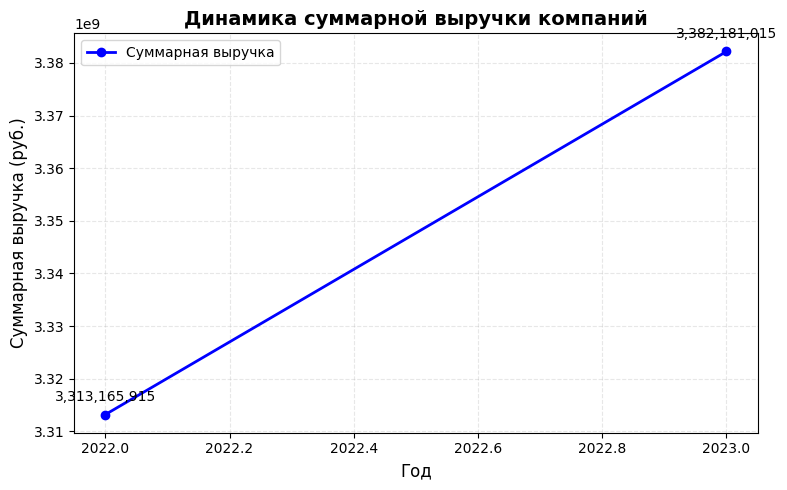

📊 Суммарная выручка:
  2022 год: 3,313,165,915 руб.
  2023 год: 3,382,181,015 руб.


ValueError: Invalid format specifier ',+,.0f' for object of type 'float'

In [4]:
# Задание 1: Линейный график суммарной выручки по годам

# 1. Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# 2. Рассчитываем суммарную выручку по годам
# Используем np.nansum, чтобы игнорировать NaN значения при суммировании
# revenue[:, 0] — выручка за 2022 год (все компании, столбец 0)
# revenue[:, 1] — выручка за 2023 год (все компании, столбец 1)
total_revenue_2022 = np.nansum(revenue[:, 0])
total_revenue_2023 = np.nansum(revenue[:, 1])
total_revenue = [total_revenue_2022, total_revenue_2023]

# 3. Создаём фигуру и оси для графика
plt.figure(figsize=(8, 5))  # Размер графика: 8×5 дюймов

# 4. Строим линейный график
# years — значения по оси X ([2022, 2023])
# total_revenue — значения по оси Y (суммы выручки)
# marker='o' — добавляет точки на линию
# linewidth=2 — толщина линии
# color='blue' — цвет линии
plt.plot(years, total_revenue, marker='o', linewidth=2, color='blue', label='Суммарная выручка')

# 5. Добавляем подписи осей и заголовок
plt.xlabel('Год', fontsize=12)                    # Подпись оси X
plt.ylabel('Суммарная выручка (руб.)', fontsize=12)  # Подпись оси Y
plt.title('Динамика суммарной выручки компаний', fontsize=14, fontweight='bold')  # Заголовок

# 6. Добавляем сетку для удобства чтения
plt.grid(True, alpha=0.3, linestyle='--')  # alpha — прозрачность сетки

# 7. Добавляем подписи значений над точками
for i, (year, val) in enumerate(zip(years, total_revenue)):
    plt.annotate(f'{val:,.0f}',
                 xy=(year, val),
                 xytext=(0, 10),  # смещение текста на 10 пикселей вверх
                 textcoords='offset points',
                 ha='center',      # горизонтальное выравнивание по центру
                 fontsize=10)

# 8. Добавляем легенду
plt.legend(fontsize=10)

# 9. Оптимизируем расположение элементов, чтобы ничего не обрезалось
plt.tight_layout()

# 10. Показываем график
plt.show()

# 11. Выводим числовые значения для справки
print("📊 Суммарная выручка:")
print(f"  2022 год: {total_revenue_2022:,.0f} руб.")
print(f"  2023 год: {total_revenue_2023:,.0f} руб.")
print(f"  Изменение: {total_revenue_2023 - total_revenue_2022:,+,.0f} руб.")

### Задание 2
Постройте несколько линий: выручка каждой компании по годам (10 линий).  
Легенду упростите: используйте первые 15 символов названия.

In [ ]:
# Ваш код здесь

### Задание 3
Постройте scatter: выручка 2023 (X) vs чистая прибыль 2023 (Y).  
Добавьте линии осей x=0 и y=0.

In [ ]:
# Ваш код здесь

### Задание 4
Подпишите на scatter-графике 3 компании с максимальной выручкой 2023 (annotate).

In [ ]:
# Ваш код здесь

### Задание 5
Постройте гистограмму распределения выручки 2023 по компаниям (bins=10).

In [ ]:
# Ваш код здесь

### Задание 6
Постройте гистограмму распределения чистой прибыли 2023.  
Отдельно выведите долю компаний с отрицательной прибылью.

In [ ]:
# Ваш код здесь

### Задание 7
Сделайте субграфики 2×2:
1) Σ выручка по годам (line)  
2) Σ прибыль по годам (line)  
3) scatter 2023 (выручка–прибыль)  
4) гистограмма выручки 2023.

In [ ]:
# Ваш код здесь

### Задание 8
Постройте бар-диаграмму: топ-5 компаний по выручке 2023 (по убыванию).

In [ ]:
# Ваш код здесь

### Задание 9
Постройте boxplot: распределение выручки по годам (две коробки: 2022 и 2023).

In [ ]:
# Ваш код здесь

### Задание 10
Сохраните любой построенный график в файл `econ_plot.png` (dpi=150) и проверьте, что файл появился.

In [ ]:
# Ваш код здесь

### Задание 11
Постройте scatter в лог-шкале X: используйте `np.log1p` от выручки 2023 по оси X, прибыль 2023 по оси Y.

In [ ]:
# Ваш код здесь

### Задание 12
Постройте две линии на одном графике: Σ выручка и Σ прибыль по годам.  
Используйте `twinx()` для второй оси.

In [ ]:
# Ваш код здесь